# SIMULACIONES DIEGOD

In [2]:
### LIBRERÍAS ################################
 
import numpy as np
import matplotlib.pyplot as plt


### Simulacion 1: Masa efectivas constantes

Qué pasa cuando aumentamos por igual las masas efectivas de todas las regiones.
El Simulacion1.txt tiene la posición en energía del primer pico de transmisión para varias masas efectivas y a qué valor de masas corresponde.


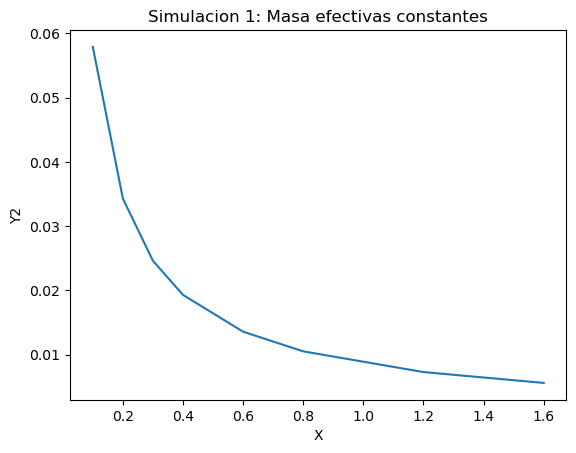

In [4]:
# Load data from the file, skipping the first row (headers)
data = np.loadtxt('prueba_masasefectivas/simulacion1.txt', skiprows=1)

# Plot X (first column) vs Y2 (second column)
plt.plot(data[:, 0], data[:, 1])
plt.xlabel('X')
plt.ylabel('Y2')
plt.title('Simulacion 1: Masa efectivas constantes')
plt.show()

Power-law fit: B = 0.0091296449697992 a = 0.8057889320483627


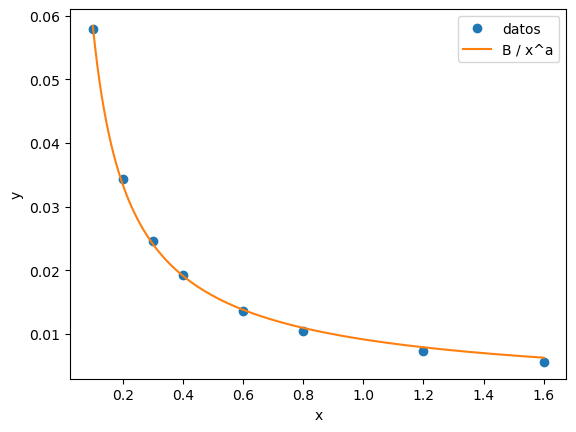

In [11]:
import scipy.optimize as opt

x = data[:, 0]
y = data[:, 1]

def power_func(x, B, a):
    return B / (x**a)

popt_pow, pcov_pow = opt.curve_fit(power_func, x, y, p0=(1.0, 1.0), bounds=(0, np.inf))

print("Power-law fit: B =", popt_pow[0], "a =", popt_pow[1])

x_fit = np.linspace(x.min(), x.max(), 200)
plt.plot(x, y, 'o', label='datos')
plt.plot(x_fit, power_func(x_fit, *popt_pow), label='B / x^a')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Simulacion 2:

Ahora ponemos las barreras desplazadas una energía 'A'. La configuración inicial es 0-0.4-0-0.4-0, luego puede ser 0.2-0.6-0.2-0.6-0.2, por ejemplo. Datos guardados en simulacion2.txt

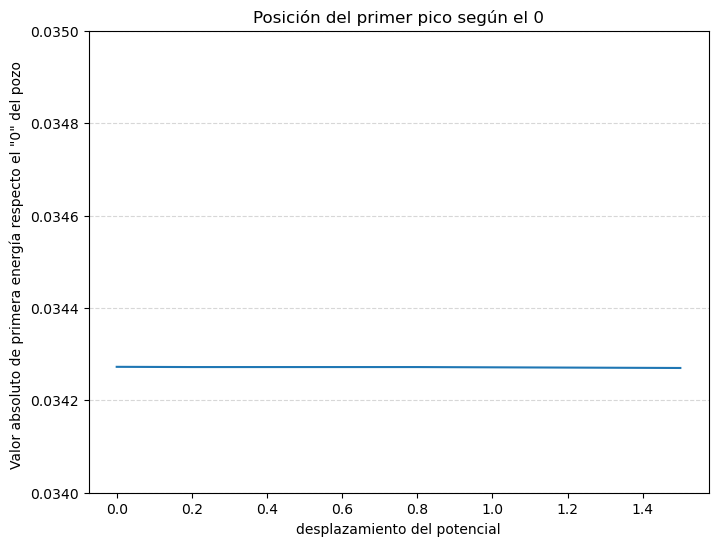

In [25]:
# Load data from simulacion2.txt, skipping the first row
data2 = np.loadtxt('prueba_masasefectivas/simulacion2.txt', skiprows=1)

# Extract x as first column, y as abs difference between first and second columns
x = data2[:, 0]
y = np.abs(data2[:, 0] - data2[:, 1])

# Plot using yticks to control the Y-axis scale / tick positions
plt.figure(figsize=(8, 6))
plt.plot(x, y)
plt.xlabel('desplazamiento del potencial')
plt.ylabel('Valor absoluto de primera energía respecto el "0" del pozo ')
plt.title('Posición del primer pico según el 0')

# Force the Y axis to start at 0.1 and show ticks from 0.1 up to the max value

plt.ylim(0.034, 0.035)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Como vemos, es cte. Confirmamos relación lineal, ajustar el 0 no tiene ningún beneficio, se trabaja con barreras de potencial.

### Simulacion 3

Ahora tenemos 'N' potenciales iguales con misma longitud. Empezaremos con 2 pozos e iremos aumentando para tener un control.
Tanto la barrera como el pozo estarán a 0.5nm y el potencial a 0.4V.

El procedimiento: Fijo la masa efectiva. Compruebo que los picos suceden a la misma energía y tienen los mismos valores pico. Miro cuál es la dispersión máxima: a un gran número de pozos cuál es el valor inicial de energía a la que pasa y cuál el final. Compruebo también que están equiespaciados. Tengo que bajar mucho la precisión si quiero monitorear la misma familia, pongo la homogeneous energy resolution en 1e-05. Trabajaré con la tercera familia que aparece claramanete con m=0.1 .

Notación:
- Mb (masa efectiva barrera)
- Mp (masa efectiva pozo)    
- Y1 (posición de energía donde se da el pico)
- Z1 (final de la familia (energia))  
- Y2 (valor del pico de transmisión)   

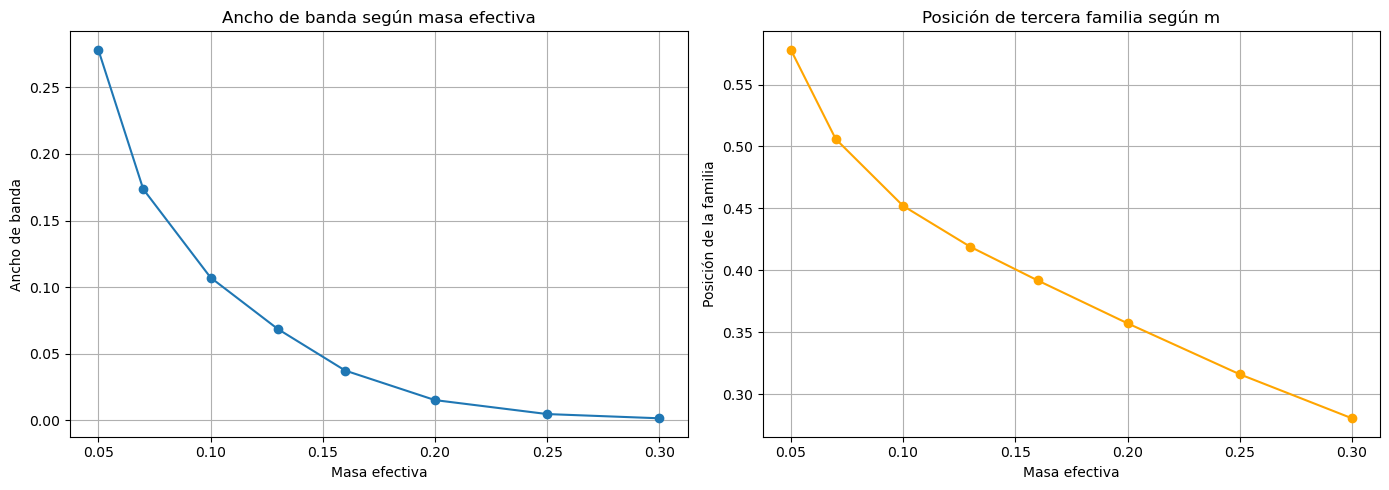

In [30]:
data3 = np.loadtxt('prueba_masasefectivas/simulacion3.txt', skiprows=1)

x = data3[:, 0]
y = data3[:, 2] - data3[:, 1]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: ancho de banda según masa efectiva
axs[0].plot(x, y, marker='o')
axs[0].set_xlabel('Masa efectiva')
axs[0].set_ylabel('Ancho de banda')
axs[0].set_title('Ancho de banda según masa efectiva')
axs[0].grid(True)

# Right plot: primera columna vs segunda columna de simulacion3.txt
axs[1].plot(data3[:, 0], data3[:, 1], marker='o', color='orange')
axs[1].set_xlabel('Masa efectiva')
axs[1].set_ylabel('Posición de la familia')
axs[1].set_title('Posición de tercera familia según m')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Exponential fit: A = 1.1663637556891682 b = 13.553069914916573 c = 0.7474402112818336


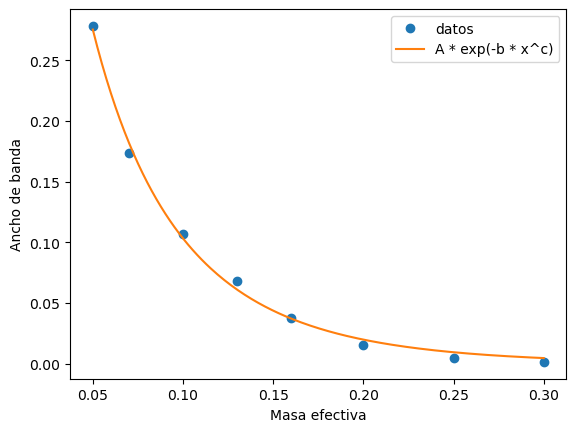

In [31]:
import scipy.optimize as opt

def exp_func(x, A, b, c):
    return A * np.exp(-b * x**c)

popt_exp, pcov_exp = opt.curve_fit(exp_func, x, y, p0=(0.3, 1.0, 1.0), bounds=(0, np.inf))

print("Exponential fit: A =", popt_exp[0], "b =", popt_exp[1], "c =", popt_exp[2])

x_fit = np.linspace(x.min(), x.max(), 200)
plt.figure()
plt.plot(x, y, 'o', label='datos')
plt.plot(x_fit, exp_func(x_fit, *popt_exp), label='A * exp(-b * x^c)')
plt.xlabel('Masa efectiva')
plt.ylabel('Ancho de banda')
plt.legend()
plt.show()

##### Conclusiones:

No están equiespaciados, están agrupados tanto cuando empieza como cuando termina la familia. Sin embargo, si hay 50 están agrupados 3 o 4 en cada esquina, y el resto están equiespaciados. La diferencia relativa era del orden del tercer decimal. 

El ancho de banda depende exponencialmente con la inversa de la masa^0.747, por lo que si queremos un pico muy definido tenemos que tener una masa efectiva muy alta. 

### Cosas que me gustaría mirar/Ideas:

- Si bien aumentando la masa barrera o aumentando la masa del pozo conseguimos que la familia se haga más ancha o más estrecha.
- Podemos hacer que los gnomos se quieren comunicar y saben que los rivales tienen un material que puede usar hasta 0.5 eV, pues algo que tenga un pico de transmisión más alejado que esos 0.5 eV.
- Buscar un único pico de transmisión con una banda muy cerrada y una precisión altísima para eso mismo, sintonizarla.
- Buscar el c=0.5 del exponente de la simulacion3 para intentar validar la ley de cuantica. Para ello, probar: hacer las barreras más altas y anchas, dejar la masa fija en pozos o variarla solo en las barreras. 